# EDA: Store Item Demand
Exploring daily sales across 10 stores and 50 items to pick a forecasting target.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv('/train.csv', parse_dates=['date'])
test = pd.read_csv('/test.csv', parse_dates=['date'])
sample_submission = pd.read_csv('/sample_submission.csv')

print("Data loaded successfully!")
print("Train head:")
train.head()

Data loaded successfully!
Train head:


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [2]:
print(train.shape)
print(train['store'].nunique(), 'stores,', train['item'].nunique(), 'items')
print(train['date'].min(), 'to', train['date'].max())
train.isnull().sum()

(913000, 4)
10 stores, 50 items
2013-01-01 00:00:00 to 2017-12-31 00:00:00


date     0
store    0
item     0
sales    0
dtype: int64

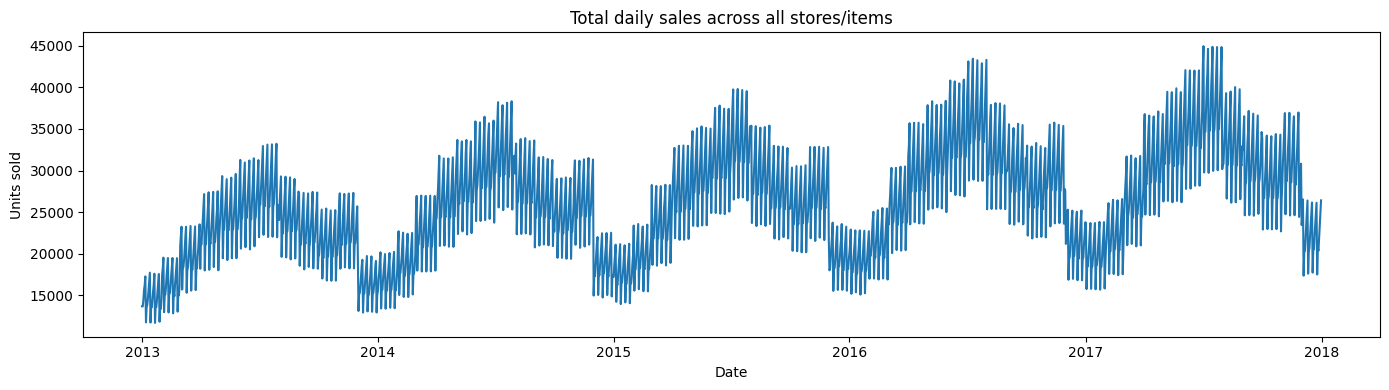

In [3]:
daily_total = train.groupby('date')['sales'].sum().reset_index()
plt.figure(figsize=(14,4))
plt.plot(daily_total['date'], daily_total['sales'])
plt.title('Total daily sales across all stores/items')
plt.xlabel('Date'); plt.ylabel('Units sold')
plt.tight_layout()
plt.savefig('total_daily_sales.png', dpi=100)
plt.show()

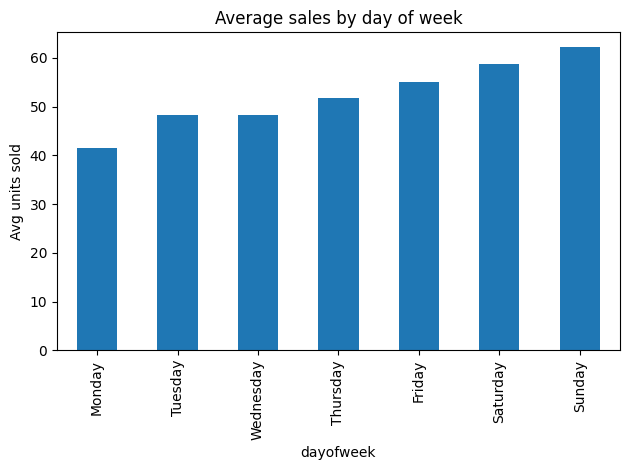

In [4]:
train['dayofweek'] = train['date'].dt.day_name()
weekly = train.groupby('dayofweek')['sales'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
weekly.plot(kind='bar', title='Average sales by day of week')
plt.ylabel('Avg units sold')
plt.tight_layout()
plt.savefig('weekly_pattern.png', dpi=100)
plt.show()

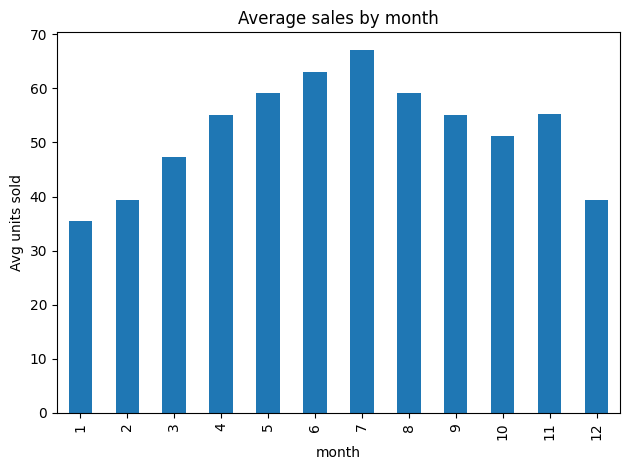

In [5]:
train['month'] = train['date'].dt.month
monthly = train.groupby('month')['sales'].mean()
monthly.plot(kind='bar', title='Average sales by month')
plt.ylabel('Avg units sold')
plt.tight_layout()
plt.savefig('monthly_pattern.png', dpi=100)
plt.show()

## Findings
- Weekends (Saturday/Sunday) run noticeably higher than weekdays, so any forecast model needs weekly seasonality built in, not just a trend line.
- Sales peak in the summer months (June to August) and dip in winter (January, February), a clear yearly seasonal cycle.
- No missing values in the training data across 5 years of daily records for 10 stores x 50 items.
- **Item 1 (aggregated across all 10 stores) is the forecasting target for the next two notebooks** — it's a mid-volume item with a clean seasonal pattern, representative of the catalog without the noise of a low-volume outlier.